In [3]:
# imports
import importlib
import download_data
importlib.reload(download_data)
from download_data import get_merged_data
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap
import holidays

df_raw = get_merged_data()

In [ ]:
#creature new feature based on the kind of day like workday
at_holidays = holidays.Austria()

df["target"] = df["Load_Actual"].shift(-1)

df["is_weekend"] = (df["DateTime"].dt.weekday >= 5).astype(int)
df["is_holiday"] = df["DateTime"].dt.date.map(at_holidays.__contains__).astype(int)
df["day_of_week"] = df["DateTime"].dt.weekday
df["week_of_year"] = df["DateTime"].dt.isocalendar().week.astype(int) - 1
df['is_workday'] = (~df['is_weekend'] & ~df['is_holiday']).astype(int)

seconds_in_day = 24 * 60 * 60
time_in_seconds = (
        df["DateTime"].dt.hour * 3600
        + df["DateTime"].dt.minute * 60
        + df["DateTime"].dt.second
)
df["time_sin"] = np.sin(2 * np.pi * time_in_seconds / seconds_in_day)
df["time_cos"] = np.cos(2 * np.pi * time_in_seconds / seconds_in_day)

dayahead_cols = df.filter(like="DayAhead").columns
df = df.drop(columns=dayahead_cols)

# delete row pre 1.10.2018
cutoff = pd.Timestamp("2018-10-01")
df = df[df["DateTime"] >= cutoff]

# delete all rows with NaNs
full_rows = ~df.isna().any(axis=1)
last_full_idx = full_rows[full_rows].index[-1]

# Alles danach verwerfen
df = df.loc[:last_full_idx]

# add lags features
df["load_lag_1"] = df["Load_Actual"].shift(1)
df["load_lag_2"] = df["Load_Actual"].shift(2)
df["load_lag_2"] = df["Load_Actual"].shift(3)
df["load_lag_4"] = df["Load_Actual"].shift(4)
df["load_lag_96"] = df["Load_Actual"].shift(96)
df["load_diff_1"] = df["load_lag_1"] - df["load_lag_2"]
df["load_diff_4"] = df["load_lag_1"] - df["load_lag_4"]
df["load_diff_24h"] = df["load_lag_1"] - df["load_lag_96"]

# rolling-statistics
df["load_mean_1h"] = df["Load_Actual"].rolling(4).mean()
df["load_std_1h"] = df["Load_Actual"].rolling(4).std()
df["load_ramp_1h"] = df["Load_Actual"].rolling(4).max() - df["Load_Actual"].rolling(4).min()

# cycling day ot the year
DOY = df['DateTime'].dt.dayofyear
angle = 2 * np.pi * DOY / 365
df['doy_sin'] = np.sin(angle)
df['doy_cos'] = np.cos(angle)

# delete NaNs after feature Engeneering
df = df.dropna().reset_index(drop=True)
# get start and end date for weather Data
start_date = df["DateTime"].min().date()
end_date = df["DateTime"].max().date()

# example: coordinates for Vienna
latitude = 48.2082
longitude = 16.3738

# query weather data via api
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "hourly": "temperature_2m,shortwave_radiation,wind_speed_10m",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

# weather dataframe
hourly_data = data.get("hourly", {})
weather = pd.DataFrame(hourly_data)

# time column in datetime
if "time" in weather.columns:
    weather["time"] = pd.to_datetime(weather["time"])

# format and sort datatime
df = df.sort_values("DateTime")
weather = weather.sort_values("time")

# merge on datetime (left join: df ← weather)
df = pd.merge_asof(df, weather, left_on="DateTime", right_on="time", direction="backward")

# drop weather time
df = df.drop(columns=["time"])

# Parameter for the curvature strength
p = 1.2  # 1 = linear, >1 = stronger increase at extreme values

# Heating demand: stronger increase below 15 °C
df["heating_demand"] = df["temperature_2m"].apply(lambda t: (15 - t) ** p if t < 15 else 0)

# Cooling demand: stronger increase above 22 °C
df["cooling_demand"] = df["temperature_2m"].apply(lambda t: (t - 22) ** p if t > 22 else 0)

xgboost 3.0.0


C:\Users\Julia\AppData\Local\Temp\ipykernel_4848\4264550387.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"target_t+{k}"] = df["Load_Actual"].shift(-k)
C:\Users\Julia\AppData\Local\Temp\ipykernel_4848\4264550387.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"target_t+{k}"] = df["Load_Actual"].shift(-k)
C:\Users\Julia\AppData\Local\Temp\ipykernel_4848\4264550387.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

MAPE Ø über alle Horizonte: 3.56%
RMSE Ø über alle Horizonte: 347.10 kW


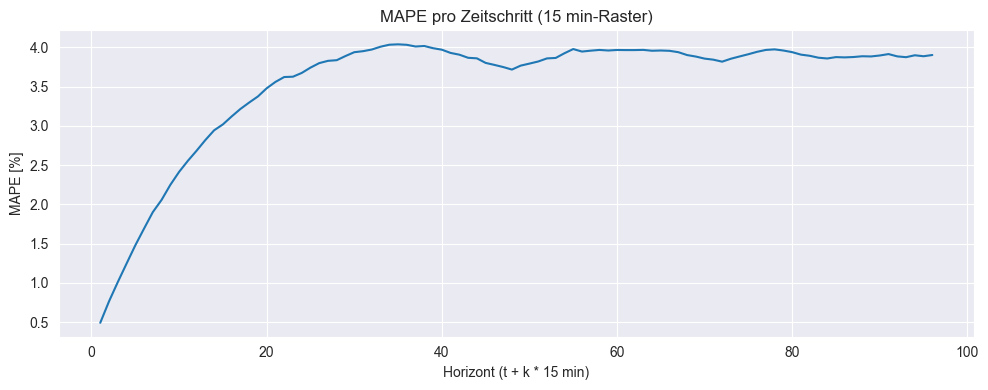

TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [41]:
# feature engineering
df = df_raw.sort_values("DateTime").reset_index(drop=True)

# calendar features
de_holidays = holidays.Germany()

df["hour"]       = df["DateTime"].dt.hour
df["quarter_hr"] = df["DateTime"].dt.minute // 15        # 0–3
df["dow"]        = df["DateTime"].dt.dayofweek           # 0=Mon … 6=Sun
df["is_weekend"] = df["dow"] >= 5
df["month"]      = df["DateTime"].dt.month
df["is_holiday"] = df["DateTime"].dt.date.isin(de_holidays)

# lag features
lags = [1, 4, 8, 12, 24, 48, 96]
for lag in lags:
    df[f"lag_{lag}"] = df["Load_Actual"].shift(lag)

# rolling statistics
df["roll_1h"]   = df["Load_Actual"].rolling(4).mean()    # 1 h
df["roll_3h"]   = df["Load_Actual"].rolling(12).mean()   # 3 h
df["roll_12h"]  = df["Load_Actual"].rolling(48).mean()   # 12 h
df["roll_24h"]  = df["Load_Actual"].rolling(96).mean()   # 24 h
df["diff_15m"]  = df["Load_Actual"].diff(1)              # short-term dynamic change

# targets
HORIZON = 96
for k in range(1, HORIZON + 1):
    df[f"target_t+{k}"] = df["Load_Actual"].shift(-k)

# clean up / final dataset
df = df.dropna().reset_index(drop=True)

feature_cols = [
    "hour", "quarter_hr", "dow", "is_weekend", "month", "is_holiday",
    *[f"lag_{lag}" for lag in lags],
    "roll_1h", "roll_3h", "roll_12h", "roll_24h", "diff_15m"
]
target_cols = [f"target_t+{k}" for k in range(1, HORIZON + 1)]

X = df[feature_cols]
y = df[target_cols]

# split train/test and create model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

base_model = xgb.XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1,
)

model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)

# evaluation
y_pred = pd.DataFrame(model.predict(X_test),
                      columns=target_cols,
                      index=y_test.index)

# error per forecast horizon
rmse_h = np.sqrt(((y_test - y_pred) ** 2).mean())
mape_h = (np.abs((y_test - y_pred) / y_test).mean()) * 100

print("Mean MAPE across all forecast steps: {:.2f}%".format(mape_h.mean()))
print("Mean RMSE across all forecast steps: {:.2f} kW".format(rmse_h.mean()))

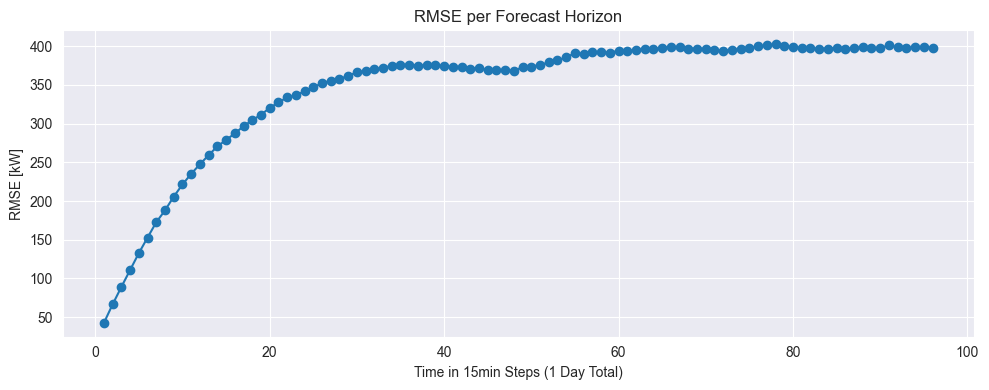

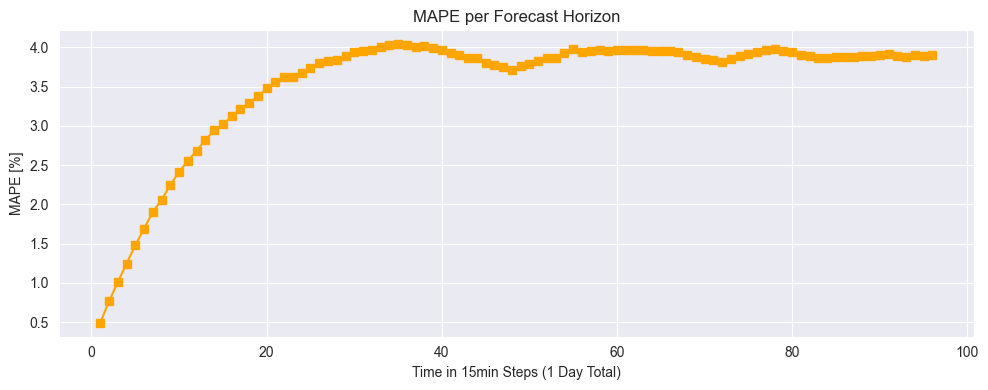

In [57]:
# MAPE & RMSE per forecast horizon
rmse_h = np.sqrt(((y_test - y_pred) ** 2).mean())
mape_h = (np.abs((y_test - y_pred) / y_test).mean()) * 100

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(rmse_h)+1), rmse_h, label="RMSE [kW]", marker="o")
plt.ylabel("RMSE [kW]")
plt.xlabel("Time in 15min Steps (1 Day Total)")
plt.grid(True)
plt.title("RMSE per Forecast Horizon")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(mape_h)+1), mape_h, label="MAPE [%]", marker="s", color="orange")
plt.ylabel("MAPE [%]")
plt.xlabel("Time in 15min Steps (1 Day Total)")
plt.grid(True)
plt.title("MAPE per Forecast Horizon")
plt.tight_layout()
plt.show()


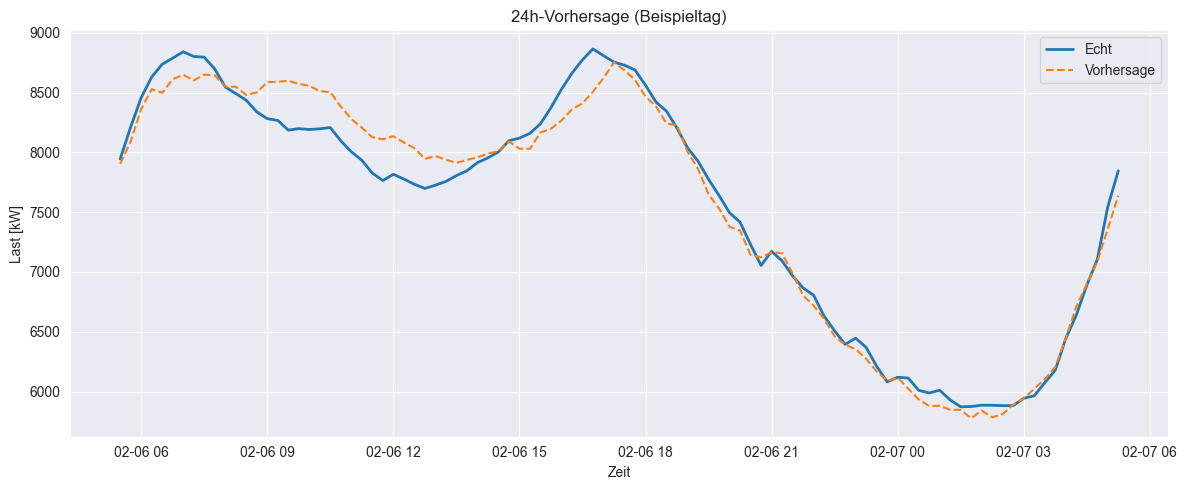

In [43]:
example_i = 0
actual_day  = y_test.iloc[example_i]
pred_day    = y_pred.iloc[example_i]

time_axis = pd.date_range(
    start=df.loc[X_test.index[example_i], "DateTime"] + pd.Timedelta(minutes=15),
    periods=96, freq="15min"
)

plt.figure(figsize=(12, 5))
plt.plot(time_axis, actual_day.values, label="Actual Demand", linewidth=2)
plt.plot(time_axis, pred_day.values, label="Predicted Demand", linestyle="--")
plt.legend()
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Demand [kW]")
plt.title("24-h-Forecast (Example Day)")
plt.tight_layout()
plt.show()


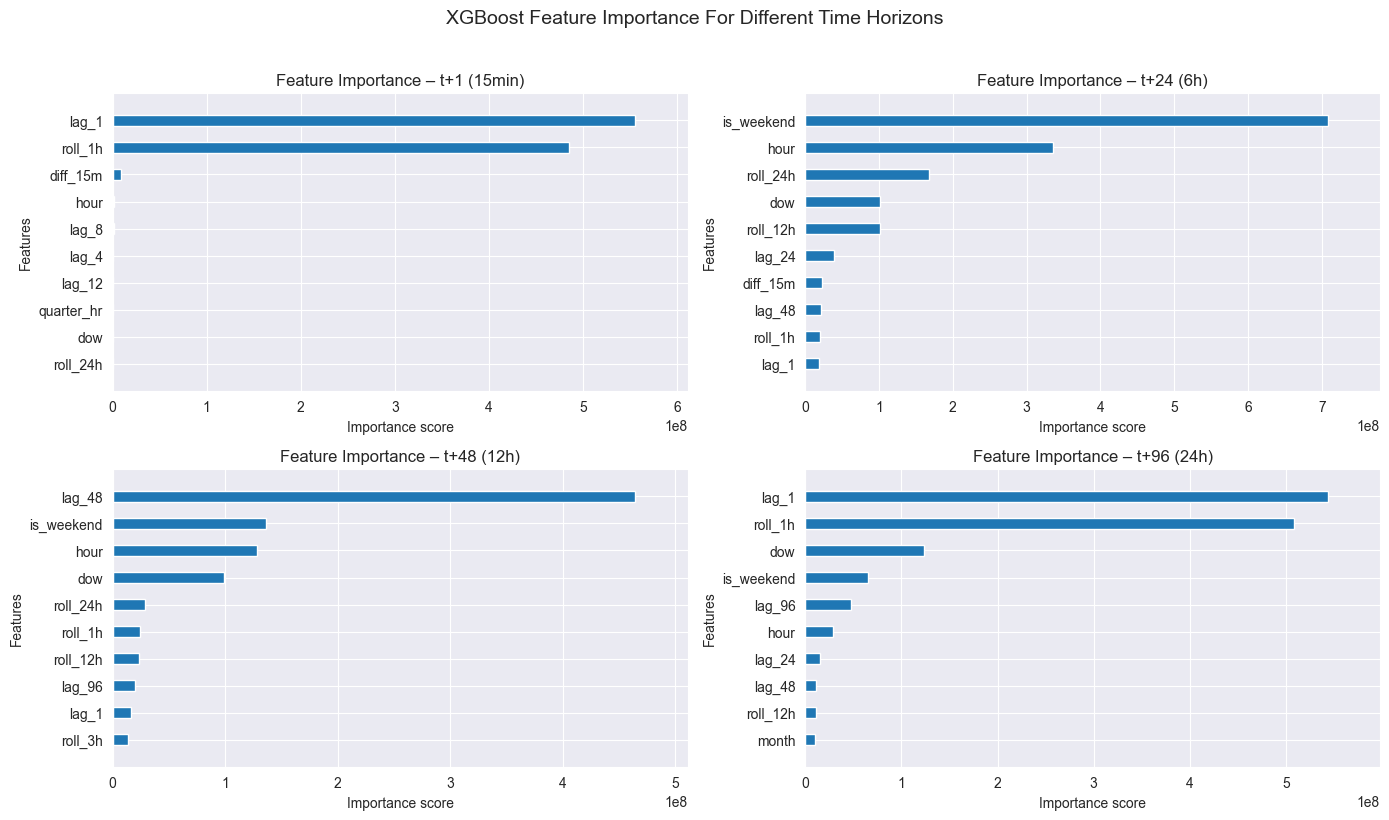

In [56]:

horizons = {
    "t+1 (15min)"   : 0,
    "t+24 (6h)"     : 23,
    "t+48 (12h)"    : 47,
    "t+96 (24h)"    : 95
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (label, idx) in enumerate(horizons.items()):
    ax = axes[i]
    xgb.plot_importance(
        model.estimators_[idx],
        ax=ax,
        max_num_features=10,
        height=0.4,
        importance_type="gain",
        show_values=False
    )
    ax.set_title(f"Feature Importance – {label}")

plt.suptitle("XGBoost Feature Importance For Different Time Horizons", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



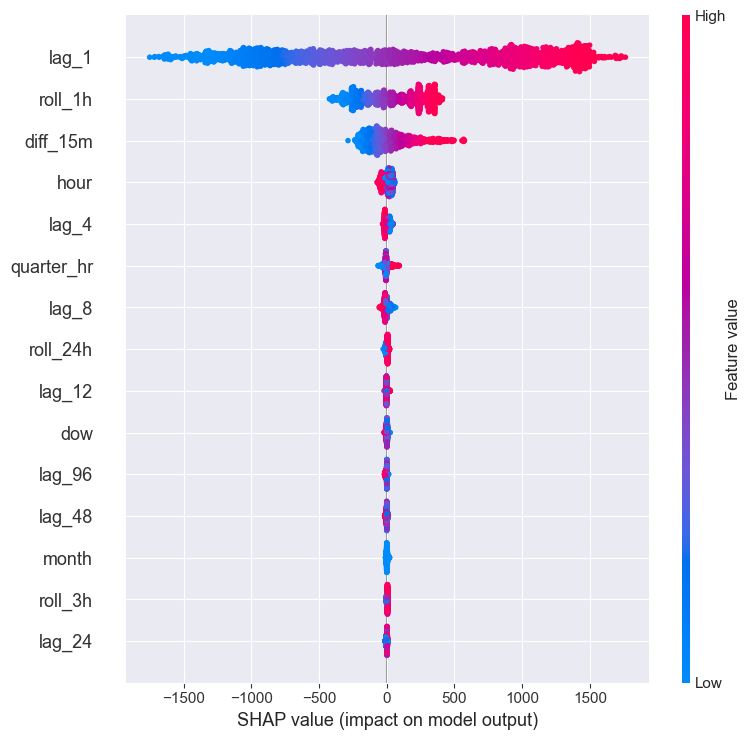

In [51]:

X_sample = X_test.iloc[:2000]
shap_vals = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_vals,
    X_sample,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.show()